<a href="https://colab.research.google.com/github/shivanshi-09/IML_Midterm/blob/main/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/shivanshi-09/IML_Midterm/main/nhanes_clean.csv')

In [15]:
X = df.drop(columns = 'RIDAGEYR').values
y = df['RIDAGEYR'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_tr = torch.tensor(X_train_s, dtype = torch.float32)
y_tr = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
X_te = torch.tensor(X_test_s, dtype = torch.float32)
y_te = torch.tensor(y_test, dtype = torch.float32).unsqueeze(1)

In [16]:
class AgeMLP(nn.Module):
  def __init__(self, inputdim):
    super().__init__()
    self.network= nn.Sequential(nn.Linear(inputdim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
                                nn.Linear(128,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
                                nn.Linear(64,32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
                                nn.Linear(32,1))
  def forward(self, x):
    return self.network(x)

In [17]:
def rmse(y_true, y_pred):
  return np.sqrt(np.mean((y_true - y_pred)**2))

def mae(y_true, y_pred):
    differences = y_pred - y_true
    absolute = np.abs(differences)
    return absolute.mean()

def pearson_r(y_true, y_pred):
    a = y_true - y_pred.mean()
    p = y_pred - y_pred.mean()
    numerator   = (a * p).sum()
    denominator = (a**2).sum()**0.5 * (p**2).sum()**0.5
    return numerator / denominator

In [18]:
model     = AgeMLP(inputdim=X_train_s.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
loader    = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

epochs = 100
for epoch in range(epochs):
  model.train()
  for X_batch, y_batch in loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
  if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch+1}/{epochs}  Loss: {loss.item():.4f}")

Epoch 10/100  Loss: 289.3045
Epoch 20/100  Loss: 198.7393
Epoch 30/100  Loss: 156.6686
Epoch 40/100  Loss: 186.5797
Epoch 50/100  Loss: 123.9141
Epoch 60/100  Loss: 132.9950
Epoch 70/100  Loss: 74.0924
Epoch 80/100  Loss: 102.0085
Epoch 90/100  Loss: 123.1545
Epoch 100/100  Loss: 85.5382


In [19]:
model.eval()
with torch.no_grad():
    pred = model(X_te).numpy().flatten()

actual      = y_test
bio_age_gap = pred - actual

print(f"\nRMSE     : {rmse(actual, pred):.3f}")
print(f"MAE      : {mae(actual, pred):.3f}")
print(f"Pearson r: {pearson_r(actual, pred):.3f}")


RMSE     : 10.287
MAE      : 7.187
Pearson r: 0.916


/tmp/ipykernel_230/3255826297.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


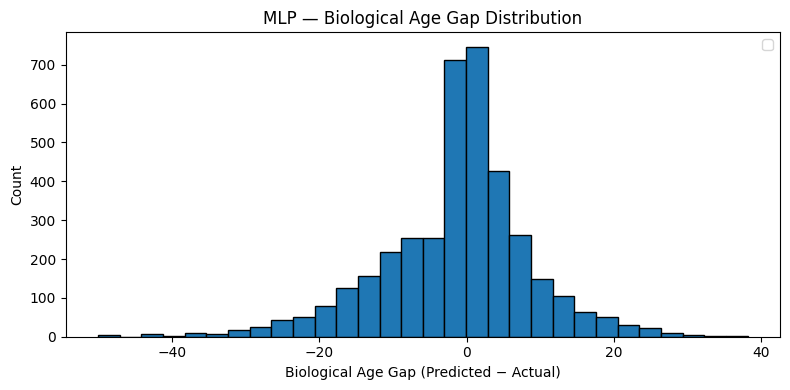

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(bio_age_gap, bins=30, edgecolor='black')
plt.xlabel("Biological Age Gap (Predicted − Actual)")
plt.ylabel("Count")
plt.title("MLP — Biological Age Gap Distribution")
plt.legend()
plt.tight_layout()
plt.show()